In [1]:
pip install mealpy --upgrade

INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ------ --------------------------------- 2.4/15.5 MB 11.2 MB/s eta 0:00:02
   ------------- -------------------------- 5.2/15.5 MB 12.8 MB/s eta 0:00:01
   -------------------- ------------------- 7.9/15.5 MB 13.2 MB/s eta 0:00:01
   --------------------------- ------------ 10.5/15.5 MB 12.8 MB/s eta 0:00:01
   ---------------------------------- ----- 13.4/15.5 MB 13.1 MB/s eta 0:00:01
   ---------------------------------------- 15.5/15.5 MB 12.7 MB/s  0:00:01
   ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
   ------- -------------------------------- 2.4/13.0 MB 12.2 MB/s eta 0:00:01
   ------------ --------------------------- 4.2/13.0 MB 11.0 MB/s eta 0:00:01
   --------------------- ------------------ 7.1/13.0 MB 11.8 MB/s eta 0:00:01
   -------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  

Import Library

In [2]:
import os
import gc
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import mealpy
from mealpy.swarm_based import WOA

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    print(f"Menggunakan GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU tidak terdeteksi, menggunakan CPU.")

Menggunakan GPU: NVIDIA GeForce RTX 5080


Konfigurasi

In [21]:
X_train_raw = np.load("X_train_raw.npy")
y_train     = np.load("y_train.npy")
X_val_raw   = np.load("X_val_raw.npy")
y_val       = np.load("y_val.npy")
X_test_raw  = np.load("X_test_raw.npy")
y_test      = np.load("y_test.npy")

with open("config.json", "r") as f:
    config = json.load(f)

TARGET_CRYSTAL_SYS = config["TARGET_CRYSTAL_SYS"]
N_POINTS           = config["N_POINTS"]
EPOCHS             = config["EPOCHS"]
BATCH_SIZE         = config["BATCH_SIZE"]
RANDOM_SEED        = config["RANDOM_SEED"]

torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

Fungsi Label Encoding

In [15]:
le = LabelEncoder()
le.classes_ = np.array(sorted(TARGET_CRYSTAL_SYS))
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
y_val_enc   = le.transform(y_val)
N_CLASSES   = len(le.classes_)

X_train_pt = torch.tensor(X_train_raw, dtype=torch.float32).unsqueeze(1)
y_train_pt = torch.tensor(y_train_enc, dtype=torch.long)

X_val_pt = torch.tensor(X_val_raw, dtype=torch.float32).unsqueeze(1)
y_val_pt = torch.tensor(y_val_enc, dtype=torch.long)

X_test_pt = torch.tensor(X_test_raw, dtype=torch.float32).unsqueeze(1)
y_test_pt = torch.tensor(y_test_enc, dtype=torch.long)

train_dataset = TensorDataset(X_train_pt, y_train_pt)
val_dataset   = TensorDataset(X_val_pt, y_val_pt)
test_dataset  = TensorDataset(X_test_pt, y_test_pt)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Konfigurasi WOA

In [35]:
WOA_N_WHALES      = 20
WOA_N_ITERATIONS  = 35
WOA_EPOCHS_TRIAL  = 100
WOA_PATIENCE_CNN  = 5
WOA_PATIENCE_ITER = 5
WOA_MIN_DELTA     = 1e-4

Konfigurasi Pencarian Hyperparameter

In [25]:
DROPOUT_CHOICES   = [0.30, 0.35, 0.40, 0.45, 0.50]

WOA_BOUNDS = [
    (15, 64),
    (3, 32),
    (3, 16),
    (0, len(DROPOUT_CHOICES) - 1),
    (2.5e-4, 5.0e-4),  # learning rate
]

def decode_woa_params(params):
    params = np.asarray(params, dtype=float)

    idx_k1 = int(np.clip(np.round(params[0]), 15, 64))
    idx_k2 = int(np.clip(np.round(params[1]), 3, 32))
    idx_k3 = int(np.clip(np.round(params[2]), 3, 16))
    idx_dc = int(np.clip(np.round(params[3]), 0, len(DROPOUT_CHOICES) - 1))
    lr     = float(np.clip(params[4], 2.5e-4, 5.0e-4))

    return {
        "kernel_1"     : idx_k1,
        "kernel_2"     : idx_k2,
        "kernel_3"     : idx_k3,
        "dropout_conv" : DROPOUT_CHOICES[idx_dc],
        "learning_rate": lr,
    }

Fungsi Arsitektur CNN dalam Optimalisasi WOA

In [36]:
class PyTorchCNN_WOA(nn.Module):
    def __init__(self, hp, input_length, n_classes):
        super(PyTorchCNN_WOA, self).__init__()
        
        filters_1 = 80
        filters_2 = 80
        filters_3 = 80
        dense_units = 700
        fc2_units = 70
        dropout_dense = 0.5
        
        # padding='same' valid jika stride=1
        self.conv1 = nn.Conv1d(1, filters_1, kernel_size=hp["kernel_1"], padding='same')
        self.pool1 = nn.AvgPool1d(kernel_size=3, stride=2)
        self.drop1 = nn.Dropout(hp["dropout_conv"])
        
        self.conv2 = nn.Conv1d(filters_1, filters_2, kernel_size=hp["kernel_2"], padding='same')
        self.pool2 = nn.AvgPool1d(kernel_size=3, stride=1)
        self.drop2 = nn.Dropout(hp["dropout_conv"])
        
        self.conv3 = nn.Conv1d(filters_2, filters_3, kernel_size=hp["kernel_3"], padding='same')
        self.pool3 = nn.AvgPool1d(kernel_size=3, stride=1)
        self.drop3 = nn.Dropout(hp["dropout_conv"])
        
        self.pool_final = nn.AvgPool1d(kernel_size=3, stride=1)
        
        # Kalkulasi bentuk flattening layer secara dinamis
        with torch.no_grad():
            dummy_in = torch.zeros(1, 1, input_length)
            x = self.pool1(self.conv1(dummy_in))
            x = self.pool2(self.conv2(x))
            x = self.pool3(self.conv3(x))
            x = self.pool_final(x)
            flatten_size = x.view(1, -1).size(1)
            
        self.fc1 = nn.Linear(flatten_size, dense_units)
        self.drop_fc1 = nn.Dropout(dropout_dense)
        
        self.fc2 = nn.Linear(dense_units, fc2_units)
        self.drop_fc2 = nn.Dropout(dropout_dense)
        
        self.out = nn.Linear(fc2_units, n_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.drop1(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.drop2(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        x = self.drop3(x)
        
        x = self.pool_final(x)
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.drop_fc1(x)
        
        x = F.relu(self.fc2(x))
        x = self.drop_fc2(x)
        
        x = self.out(x)
        # Tidak menggunakan softmax di sini, PyTorch CrossEntropyLoss sudah menghandlenya
        return x

In [27]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_weights = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0

def train_pytorch_model(model, lr, epochs, patience, min_delta, verbose=0):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    early_stopping = EarlyStopping(patience=patience, min_delta=min_delta)
    
    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            outputs = model(X_b)
            loss = criterion(outputs, y_b)
            loss.backward()
            optimizer.step()
            
        model.eval()
        val_loss = 0.0
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                outputs = model(X_b)
                loss = criterion(outputs, y_b)
                val_loss += loss.item() * X_b.size(0)
                
                _, predicted = torch.max(outputs, 1)
                val_total += y_b.size(0)
                val_correct += (predicted == y_b).sum().item()
                
        val_loss /= val_total
        val_acc = val_correct / val_total
        
        if verbose > 0:
            print(f"Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")
            
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            if verbose > 0:
                print("Early stopping terpicu!")
            break
            
    model.load_state_dict(early_stopping.best_weights)
    return early_stopping.best_loss

Fungsi Best Fitness

In [30]:
def run_woa(label="CNN + WOA (Mealpy)"):
    print("=" * 65)
    print(f"  {label}")
    print("=" * 65)
    print(f"  Whales            : {WOA_N_WHALES}")
    print(f"  Iterations        : {WOA_N_ITERATIONS}")
    print(f"  Epochs per whale  : {WOA_EPOCHS_TRIAL}")
    print(f"  Patience CNN      : {WOA_PATIENCE_CNN}")
    print(f"  Patience iter WOA : {WOA_PATIENCE_ITER}")
    print("=" * 65)

    fitness_cache = {}

    def fitness_function(solution):
        hp  = decode_woa_params(solution)
        key = tuple(sorted(hp.items()))

        if key in fitness_cache:
            return fitness_cache[key]

        try:
            # Bangun model
            mdl = PyTorchCNN_WOA(hp, N_POINTS, N_CLASSES)
            
            # Lakukan training dengan fungsi manual PyTorch
            best_val_loss = train_pytorch_model(
                model=mdl, 
                lr=hp["learning_rate"], 
                epochs=WOA_EPOCHS_TRIAL, 
                patience=WOA_PATIENCE_CNN, 
                min_delta=WOA_MIN_DELTA,
                verbose=0
            )

            fitness_cache[key] = best_val_loss

            # Bersihkan memori GPU dengan eksplisit 
            del mdl
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()

            return best_val_loss

        except Exception as e:
            print(f"  ⚠ fitness error: {e}")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()
            return float('inf')

    lb = [b[0] for b in WOA_BOUNDS]
    ub = [b[1] for b in WOA_BOUNDS]

    problem_dict = {
        "bounds": mealpy.FloatVar(lb=lb, ub=ub),
        "minmax": "min",
        "obj_func": fitness_function,
        "log_to": "console", 
    }

    term_dict = {
        "max_epoch"      : WOA_N_ITERATIONS,   
        "max_early_stop" : WOA_PATIENCE_ITER,  
    }

    optimizer = WOA.OriginalWOA(epoch=WOA_N_ITERATIONS, pop_size=WOA_N_WHALES)
    
    print("  Menjalankan Mealpy WOA...")
    g_best = optimizer.solve(problem_dict, seed=RANDOM_SEED, termination=term_dict)

    best_params = g_best.solution
    best_fitness = g_best.target.fitness
    best_hp = decode_woa_params(best_params)

    fitness_hist = optimizer.history.list_global_best_fit

    print("" + "=" * 65)
    print("  HASIL TUNING WOA TERBAIK")
    print("=" * 65)
    print(f"  Best val_loss : {best_fitness:.4f}")

    for k, v in best_hp.items():
        if k == "learning_rate":
            print(f"  - {k:<14}: {v:.2e}")
        else:
            print(f"  - {k:<14}: {v}")

    print("=" * 65)

    return best_params, best_hp, best_fitness, fitness_hist, optimizer



Tuning WOA

In [37]:
best_params_woa, best_hp_woa, best_fitness_woa, fitness_hist_woa, optimizer_woa = run_woa(
    label="WOA Hyperparameter Tuning untuk 1D-CNN (via Mealpy & PyTorch)"
)

2026/06/22 07:05:56 PM, INFO, mealpy.swarm_based.WOA.OriginalWOA: OriginalWOA(epoch=35, pop_size=20)


  WOA Hyperparameter Tuning untuk 1D-CNN (via Mealpy & PyTorch)
  Whales            : 20
  Iterations        : 35
  Epochs per whale  : 100
  Patience CNN      : 5
  Patience iter WOA : 5
  Menjalankan Mealpy WOA...


2026/06/22 08:02:43 PM, INFO, mealpy.swarm_based.WOA.OriginalWOA: >>>Problem: P, Epoch: 1, Current best: 0.10668050990855381, Global best: 0.10668050990855381, Runtime: 1708.91149 seconds
2026/06/22 08:21:39 PM, INFO, mealpy.swarm_based.WOA.OriginalWOA: >>>Problem: P, Epoch: 2, Current best: 0.10230184074032389, Global best: 0.10230184074032389, Runtime: 1136.36648 seconds
2026/06/22 08:39:29 PM, INFO, mealpy.swarm_based.WOA.OriginalWOA: >>>Problem: P, Epoch: 3, Current best: 0.10230184074032389, Global best: 0.10230184074032389, Runtime: 1070.59991 seconds
2026/06/22 08:57:01 PM, INFO, mealpy.swarm_based.WOA.OriginalWOA: >>>Problem: P, Epoch: 4, Current best: 0.09709204865552339, Global best: 0.09709204865552339, Runtime: 1051.90735 seconds
2026/06/22 09:21:28 PM, INFO, mealpy.swarm_based.WOA.OriginalWOA: >>>Problem: P, Epoch: 5, Current best: 0.09709204865552339, Global best: 0.09709204865552339, Runtime: 1466.76865 seconds
2026/06/22 09:28:22 PM, INFO, mealpy.swarm_based.WOA.Origina

  HASIL TUNING WOA TERBAIK
  Best val_loss : 0.0971
  - kernel_1      : 64
  - kernel_2      : 24
  - kernel_3      : 16
  - dropout_conv  : 0.5
  - learning_rate : 5.00e-04


Kurva Konvergen

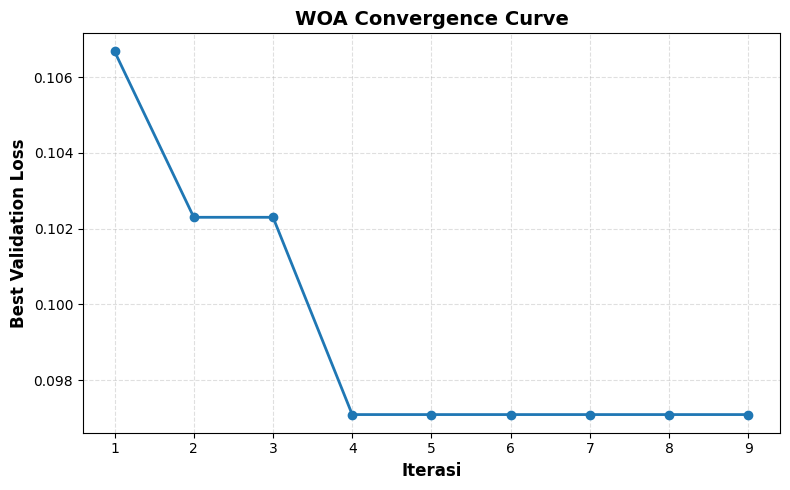

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    range(1, len(fitness_hist_woa) + 1),
    fitness_hist_woa,
    marker="o",
    linewidth=2
)
ax.set_title("WOA Convergence Curve", fontweight="bold", fontsize=14)
ax.set_xlabel("Iterasi", fontweight="bold", fontsize=12)
ax.set_ylabel("Best Validation Loss", fontweight="bold", fontsize=12)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Grafik Parameter Importance

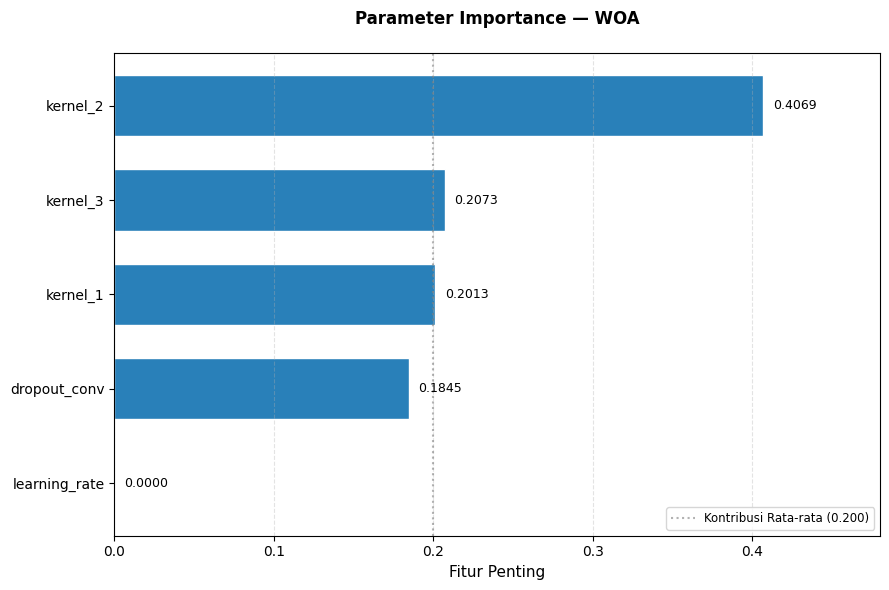


  RANDOM FOREST FEATURE IMPORTANCE — PARAMETER vs FITNESS
  Parameter           Importance    Persentase
-------------------------------------------------------
  kernel_2                0.4069        40.69%  ★
  kernel_3                0.2073        20.73%  ★
  kernel_1                0.2013        20.13%  ★
  dropout_conv            0.1845        18.45%   
  learning_rate           0.0000         0.00%   
  ★ = Parameter dengan pengaruh di atas rata-rata (≥ 0.2000)


In [40]:
param_names = [
    "kernel_1",     "kernel_2",     "kernel_3",
    "dropout_conv", 
    "learning_rate"
]

history_agents = optimizer_woa.history.list_global_best  # list of Agent objects

param_matrix = []
fitness_list = []

for agent in history_agents:
    hp = decode_woa_params(agent.solution)
    param_matrix.append([hp[k] for k in param_names])
    fitness_list.append(agent.target.fitness)

param_matrix = np.array(param_matrix)   # shape: (n_iters, 11)
fitness_arr  = np.array(fitness_list)    # shape: (n_iters,)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(param_matrix, fitness_arr)

importances = rf_model.feature_importances_

sorted_idx = np.argsort(importances)   

sorted_names = [param_names[i]  for i in sorted_idx]
sorted_importances = [importances[i] for i in sorted_idx]

colors = ["#2980b9" for _ in range(len(param_names))]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    sorted_names, sorted_importances,
    color=colors, edgecolor="white", height=0.65
)

for bar, imp in zip(bars, sorted_importances):
    ax.text(
        bar.get_width() + (max(importances) * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{imp:.4f}", va="center", ha="left", fontsize=9
    )

ax.set_xlabel("Fitur Penting", fontsize=11)
ax.set_title(
    "Parameter Importance — WOA\n",
    fontweight="bold", fontsize=12
)

ax.set_xlim(0, max(importances) * 1.18 if max(importances) > 0 else 1.0)

mean_importance = 1.0 / len(param_names)
ax.axvline(mean_importance, color="gray", linestyle=":", alpha=0.6, 
           label=f"Kontribusi Rata-rata ({mean_importance:.3f})")

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.legend(loc="lower right", fontsize=8.5)

plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print("  RANDOM FOREST FEATURE IMPORTANCE — PARAMETER vs FITNESS")
print("=" * 55)
print(f"  {'Parameter':<16}  {'Importance':>12}  {'Persentase':>12}")
print("-" * 55)

for name, imp in sorted(zip(param_names, importances), key=lambda x: -x[1]):
    star_marker = "★" if imp >= mean_importance else " "
    print(f"  {name:<16}  {imp:>12.4f}  {imp*100:>11.2f}%  {star_marker}")

print("=" * 55)
print(f"  ★ = Parameter dengan pengaruh di atas rata-rata (≥ {mean_importance:.4f})")

In [47]:
# =============================================================================
# PASTIKAN HANYA ADA SATU FUNGSI INI DI SELURUH NOTEBOOK
# =============================================================================
def train_pytorch_model(model, lr, epochs, patience, min_delta, verbose=0):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    early_stopping = EarlyStopping(patience=patience, min_delta=min_delta)
    
    # List untuk menampung history training
    train_loss_hist = []
    val_loss_hist = []
    val_acc_hist = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total_train = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            outputs = model(X_b)
            loss = criterion(outputs, y_b)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * X_b.size(0)
            total_train += X_b.size(0)
            
        epoch_train_loss = running_loss / total_train
        train_loss_hist.append(epoch_train_loss)
            
        model.eval()
        val_loss = 0.0
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                outputs = model(X_b)
                loss = criterion(outputs, y_b)
                val_loss += loss.item() * X_b.size(0)
                
                _, predicted = torch.max(outputs, 1)
                val_total += y_b.size(0)
                val_correct += (predicted == y_b).sum().item()
                
        val_loss /= val_total
        val_acc = val_correct / val_total
        
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)
        
        if verbose > 0:
            print(f"Epoch {epoch+1}/{epochs} - train_loss: {epoch_train_loss:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")
            
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            if verbose > 0:
                print("Early stopping terpicu!")
            break
            
    model.load_state_dict(early_stopping.best_weights)
    
    # PERHATIKAN BARIS INI: Harus me-return 4 nilai (Tuple)
    return early_stopping.best_loss, train_loss_hist, val_loss_hist, val_acc_hist

Retrain Model CNN

In [48]:
final_model = PyTorchCNN_WOA(best_hp_woa, N_POINTS, N_CLASSES)
best_loss_final, retrain_train_loss, retrain_val_loss,  retrain_val_acc  = train_pytorch_model(
    model=final_model, 
    lr=best_hp_woa["learning_rate"], 
    epochs=EPOCHS, 
    patience=WOA_PATIENCE_CNN, 
    min_delta=WOA_MIN_DELTA,
    verbose=1
)

Epoch 1/110 - train_loss: 0.9378 - val_loss: 0.4120 - val_acc: 0.8630
Epoch 2/110 - train_loss: 0.4833 - val_loss: 0.2945 - val_acc: 0.8980
Epoch 3/110 - train_loss: 0.3468 - val_loss: 0.2515 - val_acc: 0.9300
Epoch 4/110 - train_loss: 0.2845 - val_loss: 0.1950 - val_acc: 0.9271
Epoch 5/110 - train_loss: 0.2386 - val_loss: 0.1683 - val_acc: 0.9397
Epoch 6/110 - train_loss: 0.1951 - val_loss: 0.1627 - val_acc: 0.9456
Epoch 7/110 - train_loss: 0.1779 - val_loss: 0.1515 - val_acc: 0.9417
Epoch 8/110 - train_loss: 0.1574 - val_loss: 0.1511 - val_acc: 0.9504
Epoch 9/110 - train_loss: 0.1411 - val_loss: 0.1724 - val_acc: 0.9456
Epoch 10/110 - train_loss: 0.1334 - val_loss: 0.1409 - val_acc: 0.9485
Epoch 11/110 - train_loss: 0.1219 - val_loss: 0.1685 - val_acc: 0.9466
Epoch 12/110 - train_loss: 0.1073 - val_loss: 0.1182 - val_acc: 0.9621
Epoch 13/110 - train_loss: 0.1017 - val_loss: 0.1219 - val_acc: 0.9602
Epoch 14/110 - train_loss: 0.0937 - val_loss: 0.1611 - val_acc: 0.9475
Epoch 15/110 - 

In [14]:
RETRAIN_EPOCHS   = EPOCHS
RETRAIN_PATIENCE = WOA_PATIENCE_CNN

for k, v in best_hp_woa.items():
    print(f"    {k:<20} : {v}")
print()

model_woa = build_cnn_woa(
    params       = best_hp_woa,
    input_length = N_POINTS,
    n_classes    = N_CLASSES,
    model_name   = "CNN_WOA_Retrain"
)

callbacks_retrain = [
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = RETRAIN_PATIENCE,
        min_delta            = WOA_MIN_DELTA,
        restore_best_weights = True,
        verbose              = 1
    )
]

history_retrain = model_woa.fit(
    X_train_cnn, y_train_cat,
    validation_data = (X_val_cnn, y_val_cat),
    epochs          = RETRAIN_EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks_retrain,
    verbose         = 1
)

loss_test, acc_test = model_woa.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"  Test akurasi : {acc_test * 100:.2f}%")
print(f"  Test Loss     : {loss_test:.4f}")


    filters_1            : 192
    filters_2            : 88
    filters_3            : 64
    kernel_1             : 17
    kernel_2             : 7
    kernel_3             : 9
    dense_units          : 256
    fc2_units            : 128
    dropout_conv         : 0.2
    dropout_dense        : 0.35
    learning_rate        : 0.0006872362368312971

Epoch 1/110
258/258 ━━━━━━━━━━━━━━━━━━━━ 214s 810ms/step - accuracy: 0.6968 - loss: 0.8672 - val_accuracy: 0.8552 - val_loss: 0.4243
Epoch 2/110
258/258 ━━━━━━━━━━━━━━━━━━━━ 206s 800ms/step - accuracy: 0.8294 - loss: 0.4634 - val_accuracy: 0.9077 - val_loss: 0.3004
Epoch 3/110
258/258 ━━━━━━━━━━━━━━━━━━━━ 207s 802ms/step - accuracy: 0.8822 - loss: 0.3321 - val_accuracy: 0.9164 - val_loss: 0.2370
Epoch 4/110
258/258 ━━━━━━━━━━━━━━━━━━━━ 206s 797ms/step - accuracy: 0.9033 - loss: 0.2704 - val_accuracy: 0.9242 - val_loss: 0.2155
Epoch 5/110
258/258 ━━━━━━━━━━━━━━━━━━━━ 205s 796ms/step - accuracy: 0.9167 - loss: 0.2387 - val_accuracy: 0.9223 

Grafik Riwayat Training

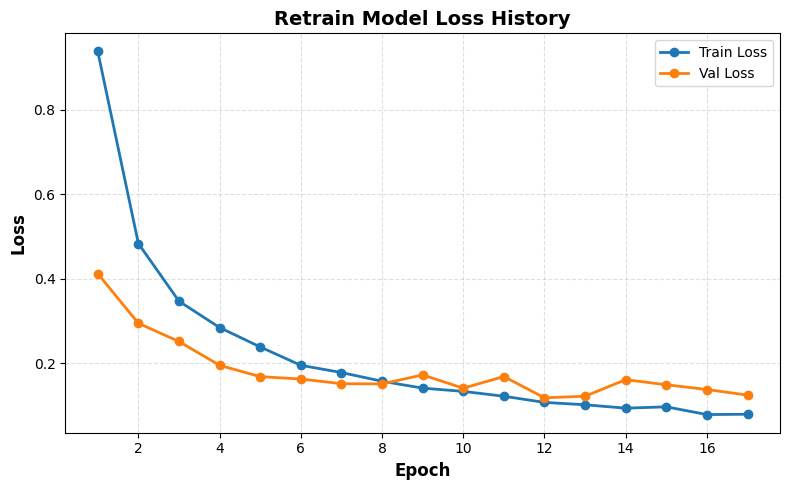

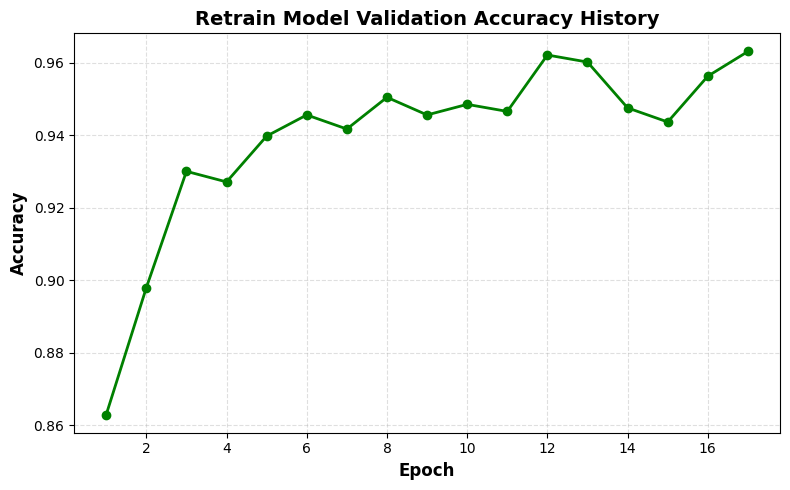

In [49]:
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(
    range(1, len(retrain_train_loss) + 1),
    retrain_train_loss,
    marker="o",
    linewidth=2,
    label="Train Loss"
)
ax2.plot(
    range(1, len(retrain_val_loss) + 1),
    retrain_val_loss,
    marker="o",
    linewidth=2,
    label="Val Loss"
)
ax2.set_title("Retrain Model Loss History", fontweight="bold", fontsize=14)
ax2.set_xlabel("Epoch", fontweight="bold", fontsize=12)
ax2.set_ylabel("Loss", fontweight="bold", fontsize=12)
ax2.grid(linestyle="--", alpha=0.4)
ax2.legend()
plt.tight_layout()
plt.show()

# Grafik Akurasi Akhir (Validation Accuracy)
fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.plot(
    range(1, len(retrain_val_acc) + 1),
    retrain_val_acc,
    marker="o",
    linewidth=2,
    color="green"
)
ax3.set_title("Retrain Model Validation Accuracy History", fontweight="bold", fontsize=14)
ax3.set_xlabel("Epoch", fontweight="bold", fontsize=12)
ax3.set_ylabel("Accuracy", fontweight="bold", fontsize=12)
ax3.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [43]:
hist        = best_loss_final.history
epochs_ran  = range(1, len(hist["accuracy"]) + 1)
best_epoch  = int(np.argmax(hist["val_accuracy"])) + 1  # epoch val_acc terbaik

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Training History — Retrain CNN + WOA\n"
    f"(Best Val Accuracy: {max(hist['val_accuracy'])*100:.2f}%  |  "
    f"Test Accuracy: {acc_test*100:.2f}%)",
    fontsize=13, fontweight="bold"
)

ax = axes[0]
ax.plot(epochs_ran, hist["accuracy"],     label="Train Accuracy",
        color="#2980b9", linewidth=2)
ax.plot(epochs_ran, hist["val_accuracy"], label="Val Accuracy",
        color="#e67e22", linewidth=2, linestyle="--")
ax.axvline(best_epoch, color="#27ae60", linestyle=":", linewidth=1.5,
           label=f"Best epoch ({best_epoch})")
ax.scatter([best_epoch], [hist["val_accuracy"][best_epoch - 1]],
           color="#27ae60", zorder=5, s=60)
ax.set_title("Akurasi", fontsize=11)
ax.set_xlabel("Epoch")
ax.set_ylabel("Akurasi")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_xlim(1, max(epochs_ran))
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.4)

ax2 = axes[1]
ax2.plot(epochs_ran, hist["loss"],     label="Train Loss",
         color="#2980b9", linewidth=2)
ax2.plot(epochs_ran, hist["val_loss"], label="Val Loss",
         color="#e67e22", linewidth=2, linestyle="--")
ax2.axvline(best_epoch, color="#27ae60", linestyle=":", linewidth=1.5,
            label=f"Best epoch ({best_epoch})")
ax2.scatter([best_epoch], [hist["val_loss"][best_epoch - 1]],
            color="#27ae60", zorder=5, s=60)
ax2.set_title("Loss", fontsize=11)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_xlim(1, max(epochs_ran))
ax2.legend(fontsize=9)
ax2.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


AttributeError: 'float' object has no attribute 'history'

Evaluasi

  EVALUASI MODEL CNN + WOA (Test Set)
  Test Accuracy        : 93.97%
  F1-Score (Macro)     : 91.19%

  Classification Report:
-----------------------------------------------------------------
              precision    recall  f1-score   support

       Kubik     0.8861    0.9323    0.9086       192
  Tetragonal     0.9362    0.7719    0.8462        57
  Ortorombik     0.9547    0.9641    0.9593       612
  Monoklinik     0.9506    0.9167    0.9333       168

    accuracy                         0.9397      1029
   macro avg     0.9319    0.8962    0.9119      1029
weighted avg     0.9402    0.9397    0.9394      1029



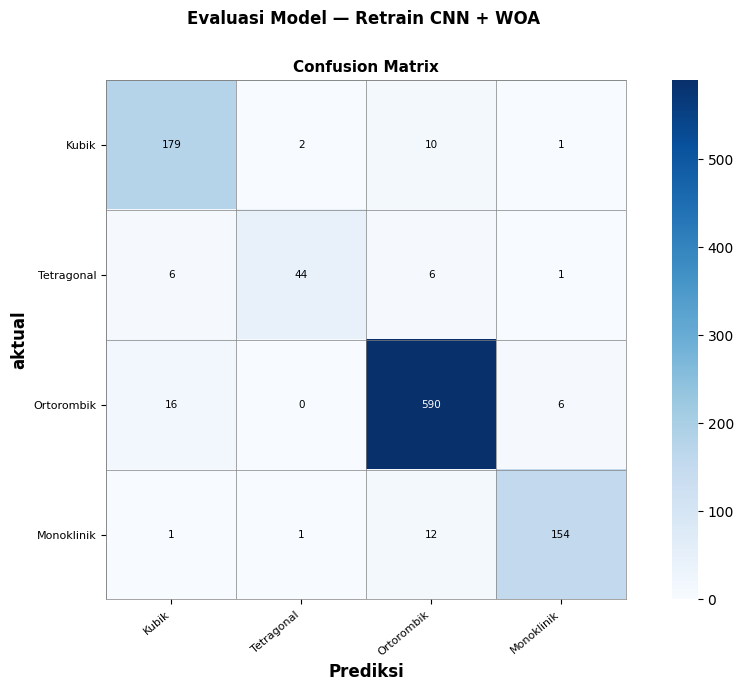

In [16]:
y_pred_prob = model_woa.predict(X_test_cnn, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test_enc

CRYSTAL_SYS_MAP = {0: "Kubik", 1: "Tetragonal", 2: "Ortorombik", 5: "Monoklinik"}
class_names = [CRYSTAL_SYS_MAP.get(int(c), str(c)) for c in le.classes_]

acc_score  = accuracy_score(y_true, y_pred)
f1_macro   = f1_score(y_true, y_pred, average="macro")

print("=" * 65)
print("  EVALUASI MODEL CNN + WOA (Test Set)")
print("=" * 65)
print(f"  Test Accuracy        : {acc_score  * 100:.2f}%")
print(f"  F1-Score (Macro)     : {f1_macro   * 100:.2f}%")
print()

report = classification_report(
    y_true, y_pred,
    target_names = class_names,  
    digits       = 4
)
print("  Classification Report:")
print("-" * 65)
print(report)

cm      = confusion_matrix(y_true, y_pred)   
n_cls   = len(class_names)

fig, axes = plt.subplots(figsize=(12, 7))
fig.suptitle("Evaluasi Model — Retrain CNN + WOA",fontsize=12, fontweight="bold", x=0.67)

def plot_cm(ax, matrix, title, fmt, cmap):
    im = ax.imshow(matrix, interpolation="nearest", cmap=cmap, vmin=0,
                   vmax=1 if fmt == ".2f" else matrix.max())
    
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.outline.set_visible(False) 

    ax.set_xticks(range(n_cls))
    ax.set_yticks(range(n_cls))
    ax.set_xticklabels(class_names, rotation=40, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Prediksi", fontsize=12, fontweight="bold")
    ax.set_ylabel("aktual",      fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=11, fontweight="bold")

    ax.set_xticks(np.arange(n_cls + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(n_cls + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False) 

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("gray")
        spine.set_linewidth(0.5)

    thresh = matrix.max() / 2.0
    for i in range(n_cls):
        for j in range(n_cls):
            val = matrix[i, j]
            ax.text(j, i, format(val, fmt),
                    ha="center", va="center", fontsize=7.5,
                    color="white" if val > thresh else "black")

plot_cm(axes, cm,      "Confusion Matrix",       "d",   "Blues")

plt.tight_layout()
fig.subplots_adjust(top=0.88) 
plt.show()

In [50]:
final_model.eval()
y_true_list, y_pred_list = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b = X_b.to(device)
        outputs = final_model(X_b)
        _, predicted = torch.max(outputs, 1)
        y_pred_list.extend(predicted.cpu().numpy())
        y_true_list.extend(y_b.numpy())

acc_score = accuracy_score(y_true_list, y_pred_list)
f1_macro = f1_score(y_true_list, y_pred_list, average="macro")

class_names = [str(cls) for cls in le.classes_]

print("=" * 65)
print("  EVALUASI MODEL CNN + WOA (Test Set)")
print("=" * 65)
print(f"  Test Accuracy      : {acc_score * 100:.2f}%")
print(f"  F1-Score (Macro)   : {f1_macro * 100:.2f}%")
print()

report = classification_report(
    y_true_list, y_pred_list,
    target_names=class_names, 
    digits=4
)
print("  Classification Report:")
print("-" * 65)
print(report)

  EVALUASI MODEL CNN + WOA (Test Set)
  Test Accuracy      : 94.56%
  F1-Score (Macro)   : 91.40%

  Classification Report:
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9409    0.9115    0.9259       192
           1     0.8800    0.7719    0.8224        57
           2     0.9477    0.9771    0.9622       612
           5     0.9630    0.9286    0.9455       168

    accuracy                         0.9456      1029
   macro avg     0.9329    0.8973    0.9140      1029
weighted avg     0.9452    0.9456    0.9449      1029



In [ ]:
#kalau memory kepenuhan
if 'fitness_hist_woa' in locals():
    del fitness_hist_woa

gc.collect()

11960

Menyimpan Model

In [52]:
model_save_path = "model_woa.pth"

torch.save(final_model.state_dict(), model_save_path)

In [51]:
model_woa.save("model_woa.h5")

NameError: name 'model_woa' is not defined